# German Sign Language Classifier — Transfer Learning

In this notebook, I apply **Transfer Learning** to build an image classifier that recognises the first three letters of German Sign Language (A, B, C). The idea is to leverage a powerful model pre-trained on ImageNet and specialise it for our specific task — rather than training a deep network from scratch.

The dataset was collected collaboratively during a Data Science & AI bootcamp: each participant photographed their own hands forming the signs, then contributed the images to a shared pool. A group-aware train/val/test split ensures the model is tested on hands it has never seen before.


---
## 1.&nbsp; Import Libraries and download the images 🛠️

In [2]:
import os
import shutil

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf

from tensorflow.data import Dataset, AUTOTUNE
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, RandomFlip, RandomRotation, RandomContrast
from tensorflow.keras.callbacks import History, EarlyStopping
from tensorflow.keras.optimizers import AdamW

from sklearn.metrics import confusion_matrix

from numpy.random import Generator
from typing import Tuple, Dict
from tensorflow.data import Dataset

In [ ]:
# Defining Dataset Loading Function
def load_datasets(
    processed_dir: str,
    batch_size: int = 32
) -> Dict[str, Dataset]:
    """
    Loads, batches, and prefetches processed data. Returns in dictionary with tf.data.Dataset objects for each split.

    Args:
        processed_dir (str): Path to directory with dir/split/Dataset structure
        batch_size (int): Batch size

    Returns:
        dict: mapping of split names to their respective tf.data.Dataset objects

    Examples:
    >>> datasets = load_datasets("../data/processed/", batch_size=32)
    >>> model.fit(
    ...     datasets['train'],
    ...     validation_data=datasets['val'],
    ...     epochs=10
    ... )
    """
    # Identify splits present in processed directory
    splits: list[str] = [
        s for s in os.listdir(processed_dir)
        if os.path.isdir(os.path.join(processed_dir, s))
    ]

    # Initialize autotune for prefetching
    autotune = tf.data.AUTOTUNE

    # Initialize dict that will be returned
    datasets: dict[str, Dataset] = {}

    for split in splits:
        # Load each dataset
        path = os.path.join(processed_dir, split)
        ds: Dataset = Dataset.load(path)
        # Batch, cache, and prefetch for optimal performance
        datasets[split]  = (
            ds
            .batch(batch_size)
            .cache()
            .prefetch(buffer_size=autotune)
        )

    return datasets

In [4]:
BATCH_SIZE: int = 32
PROCESSED_DIR = "../data/processed/"

# Load saved Dataset objects, batching and prefetching them
datasets: Dict[str, Dataset] = load_datasets(
    processed_dir=PROCESSED_DIR,
    batch_size=BATCH_SIZE
)

2026-04-08 15:09:52.185425: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-04-08 15:09:52.185447: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-08 15:09:52.185453: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-08 15:09:52.185466: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-08 15:09:52.185475: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [36]:
# How many images do we have in our datasets?

print(sum(batch[0].shape[0] for batch in datasets["train"]))
print(sum(batch[0].shape[0] for batch in datasets["test"]))
print(sum(batch[0].shape[0] for batch in datasets["val"]))

981
199
199


2026-04-10 10:00:10.636949: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-10 10:00:10.646306: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-04-10 10:00:10.650133: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


---
## 2.&nbsp; Group-Aware Data Splitting 👥

The dataset was collected collaboratively: each participant photographed their own hands forming the signs.
To ensure the model is evaluated on **hands it has never seen during training**, we use a
**group-aware split** — each person is treated as a group and kept entirely within one split.
A simple random shuffle would spread the same person's hands across train and test, making
the task much easier than it really is and inflating reported accuracy.

Expected input structure before splitting:
```
data/
  └── grouped/
       ├── person_one/
       │    ├── A/
       │    ├── B/
       │    └── C/
       ├── person_two/
       │    ├── A/
       │    ├── B/
       │    └── C/
       └── ...
```

In [ ]:
def _monte_carlo_split(
    groups_dict: dict[str, int],
    target_samples: int,
    seed: int,
    iterations: int = 1000,
) -> tuple[list[str], list[str]]:
    """
    Splits groups to approximate a target sample count without spreading any group across sets.
    Uses Monte Carlo shuffling: repeatedly shuffles groups and picks the split closest to the target.

    Args:
        groups_dict: Mapping of group names to their total image count.
        target_samples: Desired number of samples for this split.
        seed: Random seed for reproducibility.
        iterations: Number of random shuffles to try.

    Returns:
        Tuple of (selected group names, remaining group names).
    """
    if target_samples == 0:
        return [], list(groups_dict.keys())

    group_names: list[str] = list(groups_dict.keys())
    best_error: float = float("inf")
    best_split: list[str] = []
    best_remaining: list[str] = []

    for i in range(iterations):
        rng: Generator = np.random.default_rng(seed + i)
        shuffled: list[str] = rng.permutation(group_names).tolist()
        cum_sums: np.ndarray = np.cumsum([groups_dict[g] for g in shuffled])
        errors: np.ndarray = np.abs(cum_sums - target_samples)
        best_idx = int(np.argmin(errors))
        if errors[best_idx] < best_error:
            best_error = errors[best_idx]
            best_split = shuffled[:best_idx + 1]
            best_remaining = shuffled[best_idx + 1:]
            if best_error == 0:
                break

    return best_split, best_remaining


def group_aware_split(
    grouped_dir: str,
    raw_dir: str,
    test_size: float = 0.125,
    val_size: float = 0.125,
    test_seed: int = 42,
    val_seed: int = 42,
) -> None:
    """
    Splits grouped data into train/val/test without spreading any person across splits.
    Reorganises from grouped/person/label/img  →  raw/split/label/img.
    Uses symlinks on Unix to avoid duplicating images (do not delete grouped/ afterwards!).
    On Windows, images are copied instead.

    Args:
        grouped_dir: Path to data/grouped/ directory.
        raw_dir: Path where data/raw/ will be created.
        test_size: Fraction of total samples reserved for the test set.
        val_size: Fraction of total samples reserved for the validation set.
        test_seed: Seed for test set selection — keep fixed across runs.
        val_seed: Seed for val set selection — can be varied to check stability.
    """
    # Count images per group
    groups_dict: dict[str, int] = {}
    for g in os.listdir(grouped_dir):
        if g.startswith("."): continue
        group_path = os.path.join(grouped_dir, g)
        if os.path.isdir(group_path):
            img_count: int = sum(
                len([f for f in os.listdir(os.path.join(group_path, label)) if not f.startswith(".")])
                for label in os.listdir(group_path)
                if not label.startswith(".") and os.path.isdir(os.path.join(group_path, label))
            )
            groups_dict[g] = img_count

    total_samples: int = sum(groups_dict.values())
    test_groups, remaining = _monte_carlo_split(groups_dict, int(total_samples * test_size), test_seed)
    remaining_dict: dict[str, int] = {g: groups_dict[g] for g in remaining}
    val_groups, train_groups = _monte_carlo_split(remaining_dict, int(total_samples * val_size), val_seed)

    splits: dict[str, list[str]] = {"test": test_groups, "val": val_groups, "train": train_groups}
    print(f"""
    Groups in Training Set  : {", ".join(train_groups)}
    Groups in Validation Set: {", ".join(val_groups)}
    Groups in Testing Set   : {", ".join(test_groups)}
    """)

    if os.path.exists(raw_dir):
        shutil.rmtree(raw_dir)

    for split_name, group_list in splits.items():
        for group in group_list:
            group_path = os.path.join(grouped_dir, group)
            for label in os.listdir(group_path):
                source_path = os.path.join(group_path, label)
                if label.startswith(".") or not os.path.isdir(source_path):
                    continue
                dest_path = os.path.join(raw_dir, split_name, label.upper())
                os.makedirs(dest_path, exist_ok=True)
                for image_file in os.listdir(source_path):
                    if image_file.startswith("."): continue
                    src_img = os.path.abspath(os.path.join(source_path, image_file))
                    dest_img = os.path.abspath(os.path.join(dest_path, f"{group}_{label.upper()}_{image_file}"))
                    if os.name == "nt":
                        shutil.copy2(src_img, dest_img)
                    else:
                        os.symlink(src_img, dest_img)


In [ ]:
GROUPED_DIR: str = "../data/grouped/"
RAW_DIR: str = "../data/raw/"

group_aware_split(
    grouped_dir=GROUPED_DIR,
    raw_dir=RAW_DIR,
    test_size=0.125,
    val_size=0.125,
    test_seed=42,   # <--- keep fixed to preserve the test set across runs
    val_seed=42,    # <--- can be varied to check validation stability
)

After running the cell above, `data/` will look like this:
```
data/
  ├── grouped/          <--- original grouped data (do not delete — symlinks point here!)
  └── raw/              <--- created by group_aware_split()
       ├── train/
       │    ├── A/
       │    ├── B/
       │    └── C/
       ├── val/
       │    ├── A/
       │    ├── B/
       │    └── C/
       └── test/
            ├── A/
            ├── B/
            └── C/
```

### Processing Raw Images into TensorFlow Datasets 📦

Rather than reloading raw images each time, we convert them once into saved `tf.data.Dataset` objects.
This makes subsequent loading much faster. Images are resized to 256×256 and padded to preserve aspect ratio.

> **Note:** Only the training set is shuffled. Val and test sets are kept in fixed order so that
> confusion matrices and per-sample inspection remain consistent across runs.

In [ ]:
def process_raw_imgs(
    raw_dir: str,
    processed_dir: str,
) -> None:
    """
    Converts raw images into saved tf.data.Dataset objects for fast loading.
    Images are resized to 256x256 and padded to maintain aspect ratio.

    Args:
        raw_dir: Path to data/raw/ (split/label/img structure).
        processed_dir: Path where processed datasets will be saved.
    """
    splits: list[str] = [
        s for s in os.listdir(raw_dir)
        if os.path.isdir(os.path.join(raw_dir, s))
    ]

    if os.path.exists(processed_dir):
        shutil.rmtree(processed_dir)

    for split in splits:
        should_shuffle: bool = (split == "train")
        ds: Dataset = tf.keras.utils.image_dataset_from_directory(
            directory=os.path.join(raw_dir, split),
            labels="inferred",
            label_mode="int",
            image_size=(256, 256),
            shuffle=should_shuffle,
            pad_to_aspect_ratio=True,
            batch_size=None,  # batching happens at load time
        )
        ds.save(os.path.join(processed_dir, split))


In [ ]:
PROCESSED_DIR: str = "../data/processed/"

process_raw_imgs(
    raw_dir=RAW_DIR,
    processed_dir=PROCESSED_DIR,
)

After processing, the full `data/` structure looks like this:
```
data/
  ├── grouped/       <--- original grouped data (do not delete!)
  ├── raw/           <--- split data with symlinks
  └── processed/     <--- created by process_raw_imgs()
       ├── train/    <--- saved tf.data.Dataset (lightweight, fast to load)
       ├── val/
       └── test/
```
> **You only need to run Sections 2.1 and 2.2 once.** After that, skip straight to Section 3 to load the saved datasets.

---
## 3.&nbsp; Preprocessing ⚡

Pretrained models were trained on data that had already undergone some preprocessing. We need to preprocess our images the same way so that they look like the kind of thing the model was trained on.

For example, if the model is expecting images that haven't been scaled, we shouldn't scale them first or to the model they'll all look extremely dark.

But how do we know what kind of preprocessing the model needs? Lucky for us, for each pretrained model keras offers, they also have a module that contains all the preprocessing it requires.

We just have to import these modules and convert the preprocessing function into a proper keras layer so that we can place it in the pipeline. We can do this conversion with a lambda layer:

In [5]:
from tensorflow.keras.applications import efficientnet_v2
from tensorflow.keras.layers import Lambda

preprocessor: Lambda = Lambda(efficientnet_v2.preprocess_input, name='preprocessor')

> **Note:** When loading the model for inference later, make sure the preprocessor follows the structure `Lambda(<ModelName>.preprocess_input)` so it can be correctly reconstructed from the saved file.

---
## 4.&nbsp; Initialising the Backbone 🧠

When adapting a pre-trained classifier to a new task, we remove its original **classification head** and replace it with a new one trained on our data.

EfficientNet was pre-trained on ImageNet — 1000 general object classes — not on German sign language. So I keep only the **feature extractor** (the backbone), which has learned to detect edges, textures, and shapes, and attach a new head on top.

In [7]:
# this is a Google-API, which often fails that's why we use a workaround in the next cell
from tensorflow.keras.applications import EfficientNetV2B0

feature_extractor = EfficientNetV2B0(
   input_shape=(256, 256, 3),
   include_top=False, # <--- removing the classifier so we can train it on a new task
   weights='imagenet',
   include_preprocessing=True
)

feature_extractor._name = 'backbone_v2'

print(f"Modell erfolgreich geladen. Name: {feature_extractor.name}")

Modell erfolgreich geladen. Name: efficientnetv2-b0


> **Note:** If you encounter a **URL fetch failure** when initialising the feature extractor, this is usually a network/API permission issue rather than a code error. As a workaround, you can download the model weights as an `.h5` file and pass a local filepath to the `weights` parameter instead of `'imagenet'`. Only use weights from trusted sources.

In [ ]:
# B0 till B7, B7 has most layers. Future advise: check which data was used to train the model. There are also comparing websites for the models

# feature_extractor: EfficientNetB0 = EfficientNetB0
#     input_shape=(256, 256, 3),
#     include_top=False, #means excluding the classifier-head
#     weights='../pretrained_model_weights/EfficientNetB0_notop.h5', # <--- providing a filepath instead
#     name='backbone',
# )

Since I'm training a brand-new head on top of the frozen backbone, the head starts with random weights and will initially perform very poorly. If the backbone weights were not frozen during this phase, the large error signal from backpropagation would propagate all the way back and **scramble the carefully pre-trained backbone weights** — an effect sometimes called *gradient shock*.

By freezing the backbone first and only training the head, I protect those pre-trained weights until the head has stabilised enough to be trusted.

In [9]:
# Freeze pre-trained weights
feature_extractor.trainable = False

---
## 5.&nbsp; Initialising the Head 👤

The classification head is a relatively shallow dense network. Its job is to learn how to map the backbone's abstract feature representations to our three target classes (A, B, C).

Pre-trained backbones output a **stack of 2D feature maps** — not a flat vector — so they can't plug directly into a Dense layer. A `Flatten()` layer would work, but a more parameter-efficient alternative is **Global Average Pooling**.

### 5.1 Global Pooling 🌎

We've seen Max Pooling before as a method for reducing the resolution of feature maps while retaining their most notable information. With Global Pooling, we take the entire feature map and summarize it with a single number.

The most common method of global pooling is `GlobalAveragePooling()` which simply averages all the pixels in each feature map. The result is that we convert our 3D block of feature maps into a 1D list of averages. Now that the data is in a list, it can be fed into a dense network.

The biggest benefit of this method is that it vastly reduces the number of parameters in our first dense layer. If each of the feature maps in the final layer of the backbone were even as small as 7x7 pixels, using global pooling instead of flattening will reduce the number of parameters in that layer by over 98%, significantly reducing the risk of overfitting.

(Note: the pre-trained model must be fit with a head that uses GAP in order for this to work properly. Most modern models use GAP, but older models like VGG16 rely on spatial specificity being retained, so they will suffer from global pooling and should be used with `Flatten()` instead)

In [10]:
from tensorflow.keras.layers import GlobalAveragePooling2D

classifier: Sequential = Sequential([
    # Pooling feature maps
    GlobalAveragePooling2D(),

    # Hidden dense layer
    Dense(64, activation='relu'),

    # Output layer
    Dense(3, activation='softmax')
], name='classification_head')

## 6.&nbsp; Bringing it all Together ⛓

With the preprocessor, feature extractor, and classifier defined, I now combine them into a single end-to-end pipeline. Data augmentation is placed at the very front so that it only runs during training and is automatically skipped during evaluation.

In [11]:
RANDOM_SEED: int = 42

data_augmentor: Sequential = Sequential([
    RandomFlip("horizontal", seed=RANDOM_SEED),
    RandomRotation(0.9, seed=RANDOM_SEED),
    RandomContrast(factor=1, seed=RANDOM_SEED)
], name='image_augmentor')

model: Sequential = Sequential([
    Input(shape=(256, 256, 3)),
    data_augmentor,
    preprocessor,
    feature_extractor,
    classifier
], name='full_pipeline')

model.summary()

Model: "full_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_augmentor (Sequential)    │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocessor (Lambda)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 8, 8, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head             │ (None, 3)              │        82,179 │
│ (Sequential)                    │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,001,491 (22.89 MB)

 Trainable params: 82,179 (321.01 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

As expected, the vast majority of parameters belong to the frozen backbone and are **not trainable** at this stage. Only the classification head weights will be updated during the first training phase.

Now I compile and train the model. I use **AdamW** (Adam with weight decay / L2 regularisation) and **EarlyStopping** to avoid unnecessary epochs once the validation loss stops improving.

In [12]:
# Initialise optimizer with weight decay
optimizer: AdamW = AdamW(learning_rate=1e-3, weight_decay=1e-4)

# Compile model with optimizer
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Initialise early stopping
es: EarlyStopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Train
history: History = model.fit(
    datasets['train'],
    epochs=20,
    validation_data=datasets['val'],
    callbacks=[es]
)

Epoch 1/20


2026-04-08 15:09:54.808934: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


31/31 ━━━━━━━━━━━━━━━━━━━━ 13s 295ms/step - accuracy: 0.5392 - loss: 0.9119 - val_accuracy: 0.5779 - val_loss: 0.8269
Epoch 2/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.7778 - loss: 0.5651 - val_accuracy: 0.6683 - val_loss: 0.7092
Epoch 3/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step - accuracy: 0.8267 - loss: 0.4569 - val_accuracy: 0.7839 - val_loss: 0.5509
Epoch 4/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.8736 - loss: 0.3745 - val_accuracy: 0.8543 - val_loss: 0.4148
Epoch 5/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.8858 - loss: 0.3197 - val_accuracy: 0.8744 - val_loss: 0.3878
Epoch 6/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 168ms/step - accuracy: 0.9052 - loss: 0.2720 - val_accuracy: 0.8342 - val_loss: 0.4472
Epoch 7/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step - accuracy: 0.9164 - loss: 0.2569 - val_accuracy: 0.8995 - val_loss: 0.3184
Epoch 8/20
31/31 ━━━━━━━━━━━━━━━━━━━━ 5s 167ms/step - accuracy: 0.9307 - loss: 0.2211 - val_accuracy: 0.9045 - val

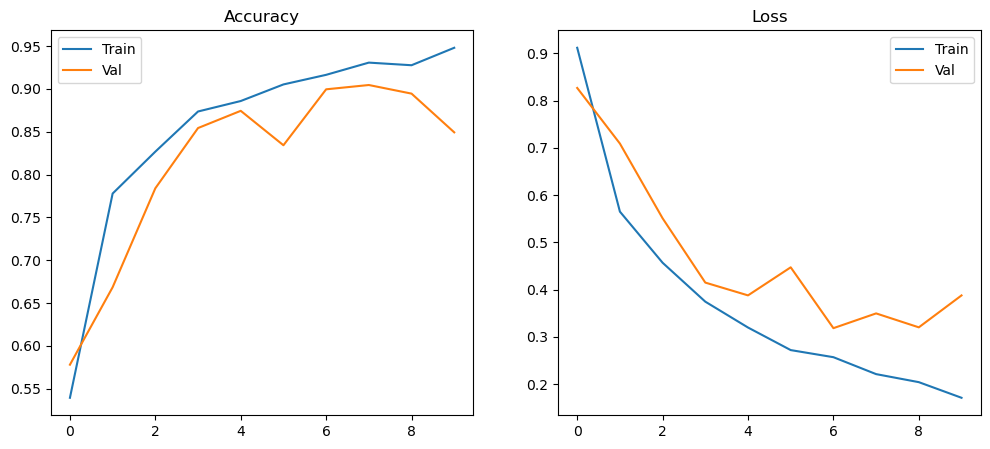

In [13]:
acc: list[float] = history.history['accuracy']
val_acc: list[float] = history.history['val_accuracy']
loss: list[float] = history.history['loss']
val_loss: list[float] = history.history['val_loss']
epochs_range: range = range(len(acc))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label='Train')
plt.plot(epochs_range, val_acc, label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label='Train')
plt.plot(epochs_range, val_loss, label='Val')
plt.title('Loss')
plt.legend()
plt.show()

---
## 7.&nbsp; Evaluating the model 🔎

Let's have a look at the test set and see where our model suceeds and fails.

In [14]:
model.evaluate(datasets['test'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - accuracy: 0.8643 - loss: 0.3841


[0.38411056995391846, 0.8643215894699097]

In [15]:
class_names: list[str] = ['A', 'B', 'C']

# Collect all images and labels from the test set
all_images: list[tf.Tensor] = []
all_labels: list[tf.Tensor] = []
for images, labels in datasets['test']:
    all_images.append(images)
    all_labels.append(labels)

all_images: tf.Tensor = tf.concat(all_images, axis=0)
all_labels: tf.Tensor = tf.concat(all_labels, axis=0)

preds: np.ndarray = model.predict(all_images)
pred_labels: np.ndarray = np.argmax(preds, axis=1)

2026-04-08 15:10:55.123516: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 488ms/step


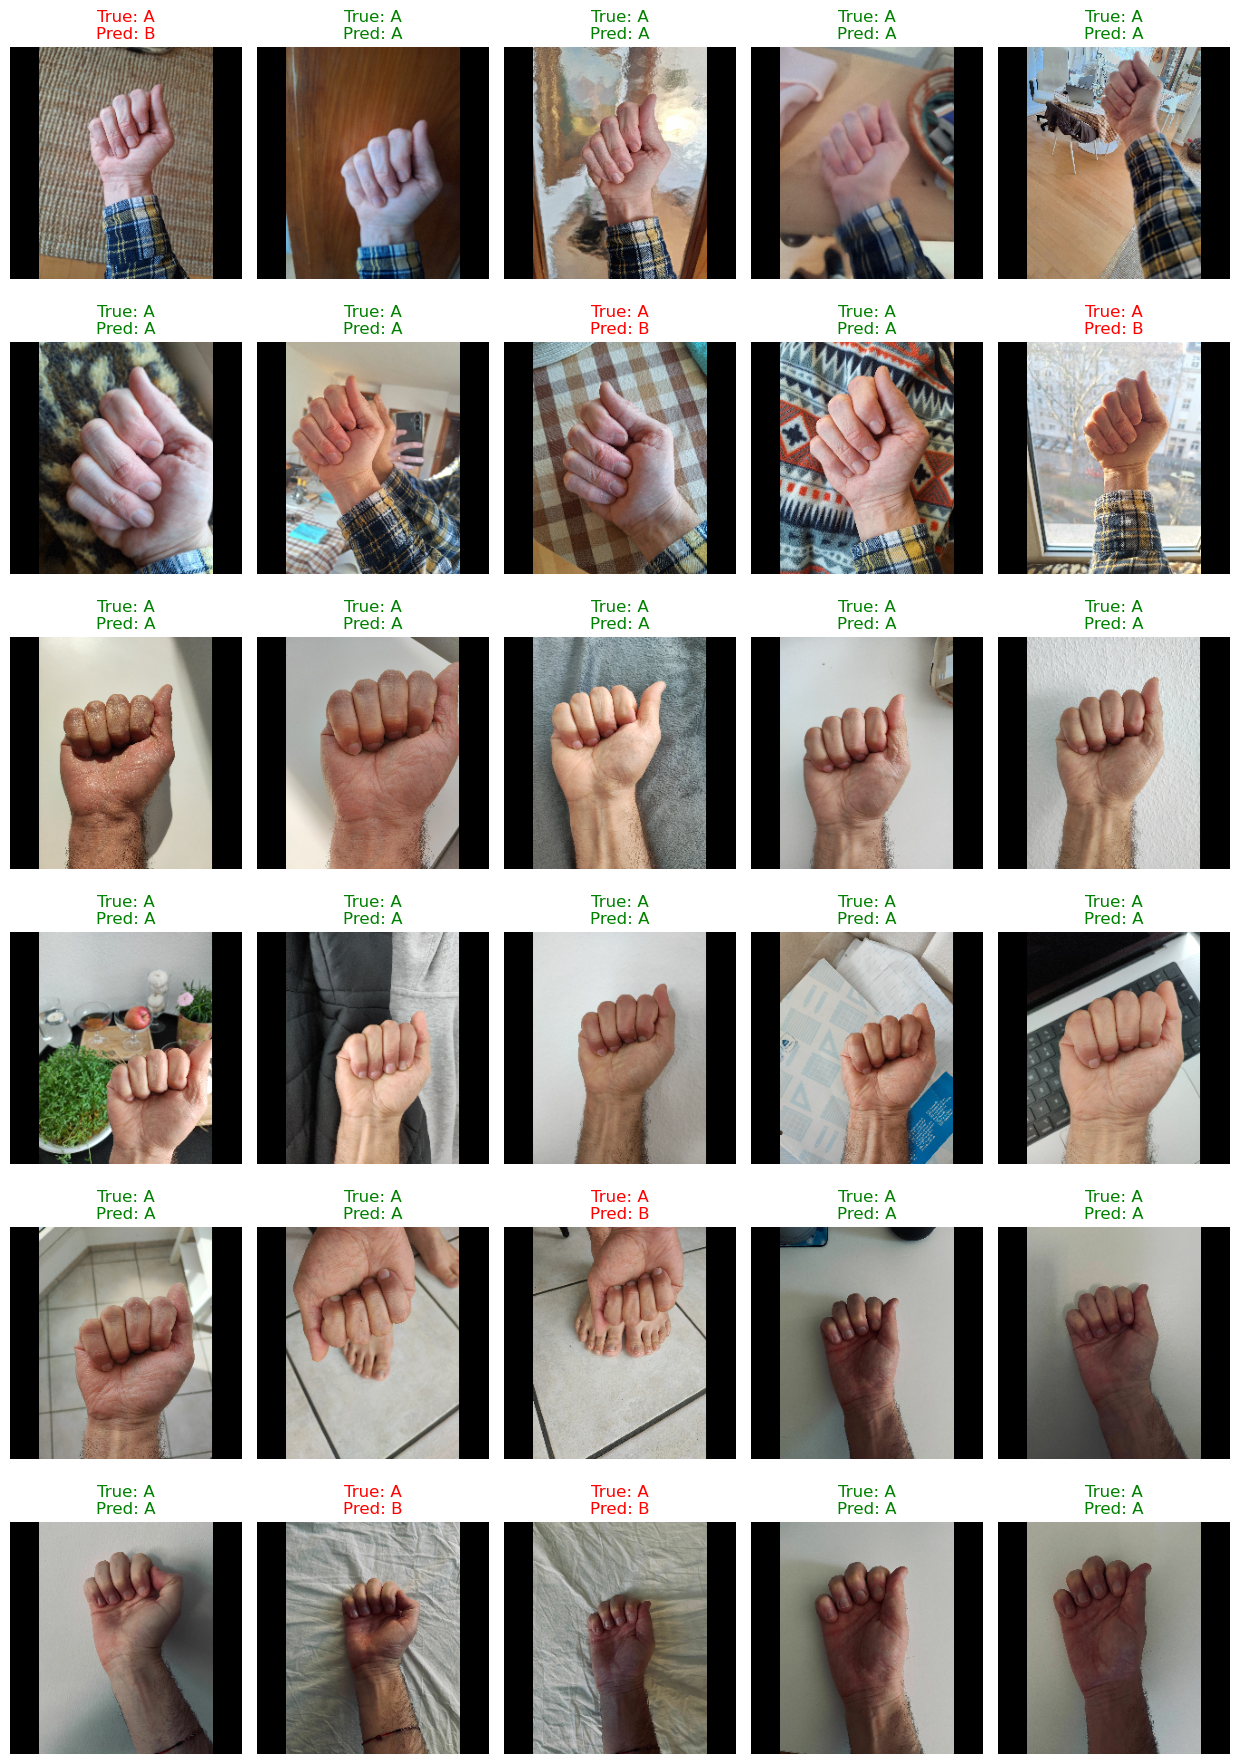

In [16]:
num_images: int = 30

# Calculate the number of rows and columns for the subplot grid
n_cols: int = 5  # You can adjust the number of columns as needed
n_rows: int = (num_images + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 2.5, n_rows * 3)) # Adjust figure size based on grid size
for i in range(num_images):
    plt.subplot(n_rows, n_cols, i + 1)
    plt.imshow(all_images[i].numpy().astype("uint8"))
    true_label: str = class_names[all_labels[i]]
    predicted_label: str = class_names[pred_labels[i]]
    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        color='green' if true_label == predicted_label else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()

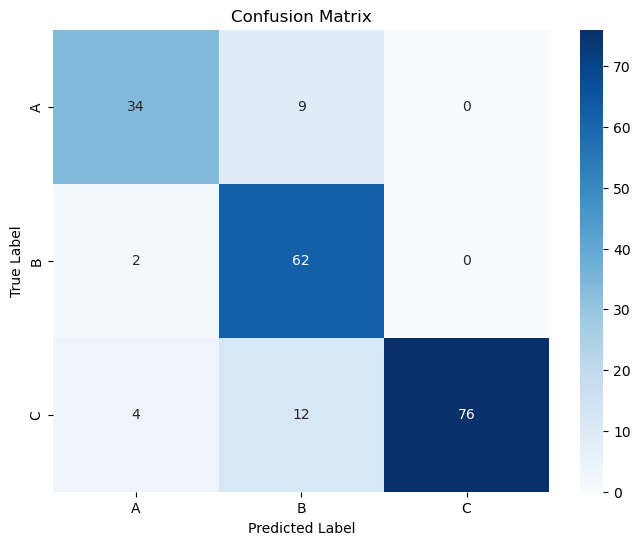

In [17]:
# Create the confusion matrix
cm: np.ndarray = confusion_matrix(all_labels, pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

The results clearly demonstrate the power of transfer learning. Starting from ImageNet weights rather than random initialisation allows the model to generalise well even with a relatively small, student-collected dataset.

---
## 8.&nbsp; Fine-Tuning 🎶

**Fine-tuning** means unfreezing the backbone and allowing its weights to be updated as well — specialising the pre-trained features further for our specific task.

This must only happen **after the classification head has been warmed up** with the backbone frozen. Unfreezing too early causes the untrained head's large gradients to destroy the pre-trained backbone weights. Once the head is stable, I unfreeze the backbone, lower the learning rate, and continue training.

Importantly: I do **not** reinitialise the model — that would reset the head. I only recompile it so the optimizer picks up the newly trainable parameters.

In [18]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_callback = ModelCheckpoint(
    filepath='best_model_finetuning.keras', # Path to the saved file
    monitor='val_loss',                     # We monitor the validation loss
    save_best_only=True,                    # Only save if the model improves
    mode='min',                             # We are looking for the minimum loss
    verbose=1                               # Log to console when the model is saved
)

# Unfreeze pre-trained weights
feature_extractor.trainable = True

# Re-initialise optimiser
optimizer: AdamW = AdamW(
    learning_rate=1e-5, # <--- decrease the learning rate to reduce the risk of catastrophic forgetting
    weight_decay=1e-5,
)

# Recompile
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    #run_eagerly=True, # <--- add this line if you get a NotImplementedError without it
)

# Train for longer
continued_history = model.fit(
    datasets['train'],
    epochs=200, # <--- WARNING: each epoch will take significantly longer, > 24 hrs!
    validation_data=datasets['val'],
    callbacks=[checkpoint_callback],
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7515 - loss: 0.5839
Epoch 1: val_loss improved from None to 0.63066, saving model to best_model_finetuning.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 138s 3s/step - accuracy: 0.7431 - loss: 0.5978 - val_accuracy: 0.7588 - val_loss: 0.6307
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7661 - loss: 0.5226
Epoch 2: val_loss did not improve from 0.63066
31/31 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.7604 - loss: 0.5250 - val_accuracy: 0.7236 - val_loss: 0.6411
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8289 - loss: 0.4101
Epoch 3: val_loss improved from 0.63066 to 0.57680, saving model to best_model_finetuning.keras
31/31 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.8349 - loss: 0.4121 - val_accuracy: 0.7638 - val_loss: 0.5768
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8246 - loss: 0.4113
Epoch 4: val_loss improved from 0.57680 to 0.54866, saving model to best_model_fi

In [ ]:
# Let's evaluate the model:

model.evaluate(datasets['test'])

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 193ms/step - accuracy: 0.9849 - loss: 0.0813


[0.08130314946174622, 0.9849246144294739]

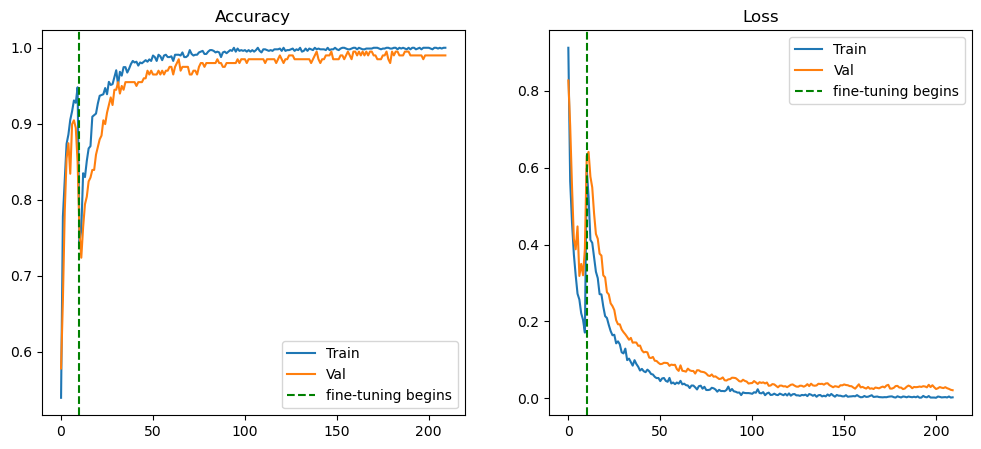

In [19]:
# Concatenating previous training history with fine-tuning history
epochs_before_fine_tuning: int = len(loss)
extended_acc: list[float] = acc + continued_history.history['accuracy']
extended_val_acc: list[float] = val_acc + continued_history.history['val_accuracy']
extended_loss: list[float] = loss + continued_history.history['loss']
extended_val_loss: list[float] = val_loss + continued_history.history['val_loss']
epochs_range: range = range(len(extended_loss))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, extended_acc, label='Train')
plt.plot(epochs_range, extended_val_acc, label='Val')
plt.axvline(x=epochs_before_fine_tuning, color='green', linestyle='--', label='fine-tuning begins')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, extended_loss, label='Train')
plt.plot(epochs_range, extended_val_loss, label='Val')
plt.axvline(x=epochs_before_fine_tuning, color='green', linestyle='--', label='fine-tuning begins')
plt.title('Loss')
plt.legend()
plt.show()

In [39]:
# Load best fine-tuned weights into the existing model
model.load_weights('best_model_finetuning.keras')

# Re-run inference on the test set with the fine-tuned model
all_images_ft, all_labels_ft = [], []
for images, labels in datasets['test']:
    all_images_ft.append(images)
    all_labels_ft.append(labels)

all_images_ft = tf.concat(all_images_ft, axis=0)
all_labels_ft = tf.concat(all_labels_ft, axis=0)

preds_ft = model.predict(all_images_ft)
pred_labels_ft = np.argmax(preds_ft, axis=1)

2026-04-10 14:29:52.333517: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step 


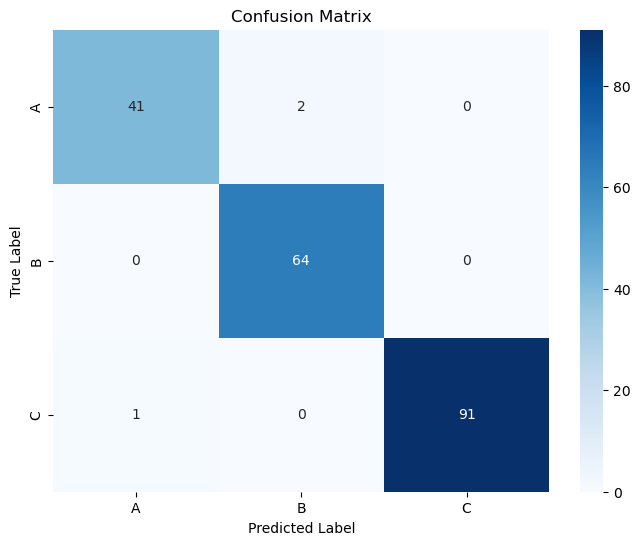

In [42]:
# Create the confusion matrix
cm: np.ndarray = confusion_matrix(all_labels_ft, pred_labels_ft)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

---
## 9.&nbsp; Save the Model

I used `ModelCheckpoint` during training to automatically save the best-performing weights. The final model can also be saved manually:

In [20]:
model.save("my_great_model_200epochs_MC.keras")

Make sure to include the `.keras` extension in the filepath. To reload a saved model that includes a custom Lambda preprocessor, pass the preprocessing function via `custom_objects`:

In [21]:
loaded_model = tf.keras.models.load_model("my_great_model_200epochs_MC.keras",
                                          custom_objects={"preprocess_input": efficientnet_v2.preprocess_input})